# BiLSTM-CRF NER Model for Custom Dataset

In [25]:

# Install required libraries
!pip install keras-crf tensorflow-addons


## Import Libraries

In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


## Load and Preprocess Dataset

In [27]:
file_path = "/content/tagged_output.csv"  # Replace with your dataset path
df = pd.read_csv(file_path)

custom_tags = [
    "O",
    "B-INVOICE",
    "I-INVOICE",
    "B-PAN",
    "I-PAN",
    "B-VENDOR",
    "I-VENDOR",
    "B-CUSTOMER",
    "I-CUSTOMER",
    "B-PHONE",
    "I-PHONE",
    "B-EMAIL",
    "I-EMAIL",
    "B-ITEM",
    "I-ITEM",
    "B-QUANTITY",
    "I-QUANTITY",
    "B-PRICE",
    "I-PRICE",
    "B-SUBTOTAL",
    "I-SUBTOTAL",
    "B-TAX",
    "I-TAX",
    "B-TOTAL",
    "I-TOTAL",
    "B-GST",
    "I-GST",
]

# Fill missing values and preprocess data
df = df.fillna(method="ffill")
all_words = list(set(df["tokens"].values))
all_tags = list(set(df["ner_tags"].values))

# Create mappings for words and tags
word2index = {word: idx + 2 for idx, word in enumerate(all_words)}
word2index["--UNKNOWN_WORD--"] = 1
word2index["--PADDING--"] = 0

tag2index = {tag: idx + 1 for idx, tag in enumerate(custom_tags)}  # Use custom_tags to ensure proper mapping
tag2index["--PADDING--"] = 0

index2word = {idx: word for word, idx in word2index.items()}
index2tag = {idx: tag for tag, idx in tag2index.items()}

# Prepare sentences and labels
grouped = df.groupby("filename")
sentences = grouped.apply(lambda s: list(zip(s["tokens"].values, s["ner_tags"].values))).tolist()
X = [[word2index.get(word[0], 1) for word in sentence] for sentence in sentences]
y = [[tag2index.get(word[1], 0) for word in sentence] for sentence in sentences]

# Pad sequences
MAX_LEN = 128
X = pad_sequences(X, maxlen=MAX_LEN, padding="post", truncating="post")
y = pad_sequences(y, maxlen=MAX_LEN, padding="post", truncating="post")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)



<ipython-input-27-9d9dd7f42472>:35: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")
<ipython-input-27-9d9dd7f42472>:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sentences = grouped.apply(lambda s: list(zip(s["tokens"].values, s["ner_tags"].values))).tolist()


## Define BiLSTM-CRF Model

In [28]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
# Model parameters
vocab_size = len(word2index)
num_tags = len(tag2index)

# Define the model
input_word = layers.Input(shape=(MAX_LEN,), dtype="int32", name="input_layer")
embedding_layer = layers.Embedding(input_dim=vocab_size, output_dim=128)(input_word)

# Force the model to use the CPU-compatible LSTM kernel
bi_lstm = layers.Bidirectional(
    layers.LSTM(units=64, return_sequences=True, dropout=0.1, recurrent_activation='sigmoid', unroll=False)
)(embedding_layer)

output = layers.TimeDistributed(layers.Dense(num_tags, activation="softmax"))(bi_lstm)

model = Model(input_word, output)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


## Train the Model

In [29]:

# Train the model
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 37s 418ms/step - accuracy: 0.4410 - loss: 2.8082 - val_accuracy: 0.6355 - val_loss: 1.4669
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.6007 - loss: 1.4045 - val_accuracy: 0.6483 - val_loss: 1.1015
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.6591 - loss: 1.0613 - val_accuracy: 0.7572 - val_loss: 0.7907
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 331ms/step - accuracy: 0.7895 - loss: 0.7255 - val_accuracy: 0.8553 - val_loss: 0.5181
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 288ms/step - accuracy: 0.8851 - loss: 0.4529 - val_accuracy: 0.9180 - val_loss: 0.3260
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.9450 - loss: 0.2596 - val_accuracy: 0.9455 - val_loss: 0.2212
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.9736 - loss: 0.1643 - val_accuracy: 0.9574 - val_loss: 0.1650
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 339ms/step - accuracy: 0.9857 - loss: 0.1096 - val_accuracy

## Evaluate the Model

In [30]:
# Predict on test data
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=-1)  # Convert predictions to class indices

# Reshape y_test if necessary
if len(y_test.shape) == 1:
    y_test = pad_sequences(y_test, maxlen=128, padding="post")

# Ensure shapes match
assert y_pred.shape == y_test.shape, f"Shape mismatch: y_pred {y_pred.shape}, y_test {y_test.shape}"

# Calculate accuracy
accuracy = (y_pred == y_test).mean()
print(f"Test Accuracy: {accuracy:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step
Test Accuracy: 0.9743


## Visualize Training Performance

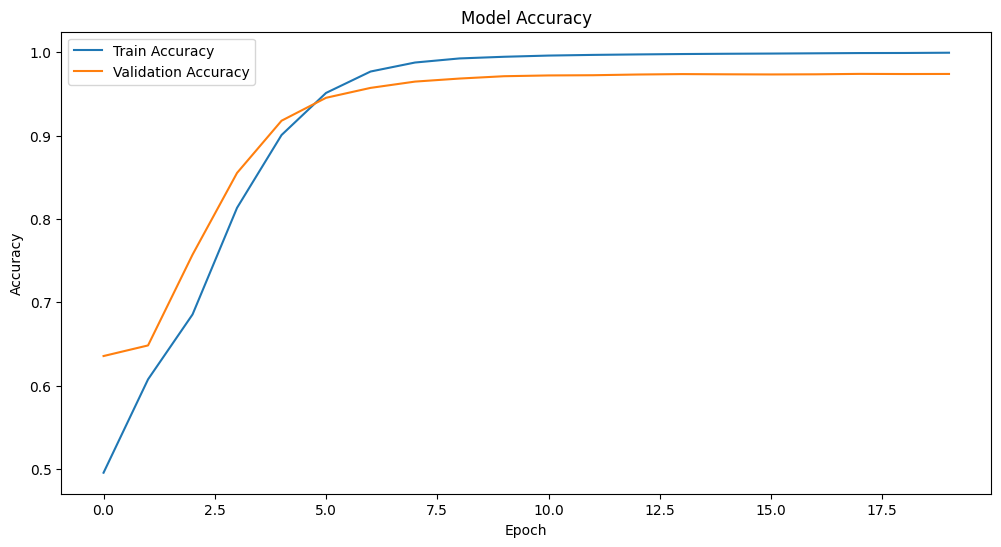

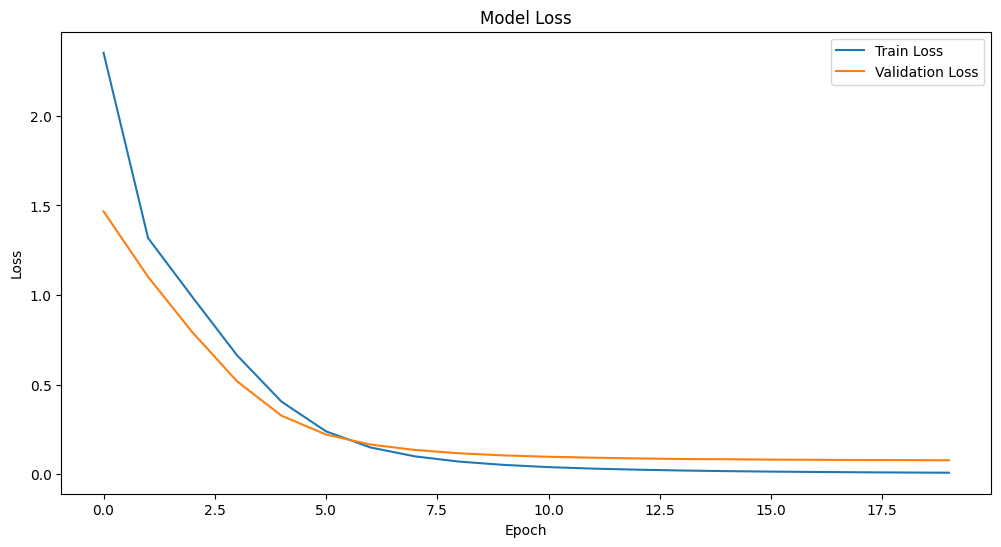

In [31]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.plot(history.history["accuracy"], label="Train Accuracy")  # Correct key
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")  # Correct key
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## Save the Model

In [32]:

# Save the model
model.save("bilstm_crf_ner.h5")
print("Model saved as bilstm_crf_ner.h5")


Model saved as bilstm_crf_ner.h5


## Convert to TensorFlow Lite

In [33]:
# Convert the model to TensorFlow Lite with Flex Ops enabled
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,  # Enable TensorFlow Lite ops
    tf.lite.OpsSet.SELECT_TF_OPS  # Enable TensorFlow Select ops
]
tflite_model = converter.convert()

# Save the TFLite model
with open("bilstm_crf_ner.tflite", "wb") as f:
    f.write(tflite_model)

print("Model saved as bilstm_crf_ner.tflite with TensorFlow Select Ops.")


Saved artifact at '/tmp/tmpplbw9z17'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128), dtype=tf.int32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 128, 28), dtype=tf.float32, name=None)
Captures:
  139420436834512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420437798528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420438130960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420848771968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420439548096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420468361552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420848776544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420848774608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420434970784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420468747728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139420434967968: Te

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load the saved BiLSTM model
bilstm_model = load_model("bilstm_crf_ner.h5")

# Load the TFLite model
tflite_interpreter = tf.lite.Interpreter(model_path="bilstm_crf_ner.tflite")
tflite_interpreter.allocate_tensors()

# Helper function to preprocess the input text
def preprocess_text(text, word2index, max_len=128):
    tokens = text.split()  # Simple whitespace tokenization
    token_indices = [word2index.get(token, word2index["--UNKNOWN_WORD--"]) for token in tokens]
    padded_sequence = pad_sequences([token_indices], maxlen=max_len, padding="post", truncating="post")
    return tokens, padded_sequence

# Helper function to decode predictions
def decode_predictions(predictions, tokens, index2tag):
    predicted_tags = [index2tag.get(idx, "O") for idx in predictions]
    return list(zip(tokens, predicted_tags))

# Input text
input_text = """
INVOICE . .
Perfect Vision Opticals
28, 1st Floor, 2nd Cross, 1st Block, RT Nagar, Mumbai-400050
GSTIN: 28AJHCU1234L1ZA PAN: RFRBG5397G
Invoice Date: 25-11-2021 Deepa Patel
Invoice No: 39787 BILL TO
P.O.No: 3888 73, Pine Boulevard
P.O.Date: 23-11-2021 Mangalore
Ref No: 5984 Pan No: EXTQG2481B
Ref Date: 25-11-2021 Mobile No: 9855902017
Email: deepapatel@gmail.com
GSTIN: 24GRZOB1843N1Z5
Description In Detail Code Qty Price IGST Discount Total
Polarized Wrap Around Sports) gag 3 3479.00 18% 521.85 9915.15
Sunglasses
Ray-Ban Aviator Classic 9005 2 2957.00 18% 295.70 5618.30
Sunglasses
Bobster Eyewear Fuel 6
Photochromic Goggles 9006 1 2684.00 18% 134.20 2549.80
TOTAL 951.75 18083.25
Sub Total 18083.25
IGST @ 18% 3254.99
Grand Total 21338.24
PAYMENT METHOD
we Accept the PayPal, Master Card, VISA and E- Wallets
Terms & Condition:
1. Goods Once Sold Will Not be Taken Back
2. Goods Can be Exchanged During 2:00 pm to 4:00 pm
Thank you for business & visit Again
"""

# Preprocess the input text
tokens, padded_sequence = preprocess_text(input_text, word2index, MAX_LEN)

# Prediction using BiLSTM model
bilstm_predictions = bilstm_model.predict(padded_sequence)
bilstm_predicted_tags = np.argmax(bilstm_predictions[0], axis=-1)
bilstm_results = decode_predictions(bilstm_predicted_tags, tokens, index2tag)

# Prediction using TFLite model
input_details = tflite_interpreter.get_input_details()
output_details = tflite_interpreter.get_output_details()

tflite_interpreter.set_tensor(input_details[0]["index"], padded_sequence.astype(np.int32))
tflite_interpreter.invoke()
tflite_predictions = tflite_interpreter.get_tensor(output_details[0]["index"])
tflite_predicted_tags = np.argmax(tflite_predictions[0], axis=-1)
tflite_results = decode_predictions(tflite_predicted_tags, tokens, index2tag)

# Function to save results to a text file
def save_results_to_file(results, output_file):
    with open(output_file, "w", encoding="utf-8") as file:
        for token, tag in results:
            file.write(f"{token}\t{tag}\n")

# Save BiLSTM model predictions
bilstm_output_file = "bilstm_predictions.txt"
save_results_to_file(bilstm_results, bilstm_output_file)
print(f"BiLSTM predictions saved to {bilstm_output_file}")

# Save TFLite model predictions
tflite_output_file = "tflite_predictions.txt"
save_results_to_file(tflite_results, tflite_output_file)
print(f"TFLite predictions saved to {tflite_output_file}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
BiLSTM predictions saved to bilstm_predictions.txt
TFLite predictions saved to tflite_predictions.txt


In [35]:
import tensorflow as tf

# Load and test the model
interpreter = tf.lite.Interpreter(model_path="bilstm_crf_ner.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Details:", input_details)
print("Output Details:", output_details)

# Check if the input shape matches the app's tensor input
input_shape = input_details[0]['shape']
print("Model Input Shape:", input_shape)
output_shape = output_details[0]['shape']
print("Model Output Shape",output_shape)

Input Details: [{'name': 'serving_default_input_layer:0', 'index': 0, 'shape': array([  1, 128], dtype=int32), 'shape_signature': array([ -1, 128], dtype=int32), 'dtype': <class 'numpy.int32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output Details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 692, 'shape': array([  1, 128,  28], dtype=int32), 'shape_signature': array([ -1, 128,  28], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Model Input Shape: [  1 128]
Model Output Shape [  1 128  28]


In [36]:
import pandas as pd
import json
from collections import Counter

# Load the dataset
file_path = "/content/tagged_output.csv"  # Replace with the actual file path
df = pd.read_csv(file_path)


# Create mappings for words and tags
word2index = {word: idx + 2 for idx, word in enumerate(all_words)}
word2index["--UNKNOWN_WORD--"] = 1
word2index["--PADDING--"] = 0

tag2index = {tag: idx + 1 for idx, tag in enumerate(custom_tags)}  # Use custom_tags to ensure proper mapping
tag2index["--PADDING--"] = 0

index2word = {idx: word for word, idx in word2index.items()}
index2tag = {idx: tag for tag, idx in tag2index.items()}

# Save the mapping as a JSON file
output_file = "word2index.json"
with open(output_file, "w") as f:
    json.dump(word2index, f, indent=4)

output_file = "tag2index.json"
with open(output_file, "w") as f:
    json.dump(tag2index, f, indent=4)

print(f"word2index and tag2index mapping saved to {output_file}")



word2index and tag2index mapping saved to tag2index.json


In [37]:
!pip install tensorflow-addons keras-crf psutil


In [40]:
import tensorflow as tf
import numpy as np
import pandas as pd
import time
import psutil
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, classification_report

# Load Word and Tag mappings
import json

with open('word2index.json') as f:
    word2index = json.load(f)

with open('tag2index.json') as f:
    tag2index = json.load(f)

index2tag = {v: k for k, v in tag2index.items()}

# Constants
MAX_LEN = 128

# -------------------------
# ✅ LOAD DATA FROM CSV
# -------------------------
print("\n🔄 Loading data from tagged_output.csv...")
df = pd.read_csv('tagged_output.csv')  # Assumes columns: 'tokens', 'ner_tags'

# Extract first 1000 tokens and tags
tokens = df['tokens'].tolist()[:1000]
true_tags = df['ner_tags'].tolist()[:1000]

# Preprocess tokens
def preprocess_text(tokens, word2index, max_len=128):
    token_indices = [word2index.get(token, word2index["--UNKNOWN_WORD--"]) for token in tokens]
    return pad_sequences([token_indices], maxlen=max_len, padding="post", truncating="post")

padded_input = preprocess_text(tokens, word2index, MAX_LEN)

# -------------------------
# ✅ HELPER FUNCTION
# -------------------------
def decode_predictions(predictions, tokens, index2tag):
    predicted_tags = [index2tag.get(idx, "O") for idx in predictions]
    return list(zip(tokens, predicted_tags))

# -------------------------
# ✅ KERAS MODEL BENCHMARK
# -------------------------
print("\n🔍 Benchmarking Keras Model...")

# Load Keras model
keras_model = load_model("bilstm_crf_ner.h5")

# Benchmark Keras Inference Speed
start_time = time.time()
for _ in range(100):
    predictions = keras_model.predict(padded_input)
end_time = time.time()
keras_time_per_inference = (end_time - start_time) / 100

# Decode predictions
keras_pred_tags = np.argmax(predictions[0], axis=-1)
keras_results = decode_predictions(keras_pred_tags, tokens, index2tag)

# Extract predicted tags for evaluation
keras_predicted_tags = [tag for _, tag in keras_results[:MAX_LEN]]

# Calculate accuracy
keras_accuracy = accuracy_score(true_tags[:MAX_LEN], keras_predicted_tags)

print(f"⚡ Avg Inference Time (Keras): {keras_time_per_inference:.4f} seconds")
print(f"🎯 Accuracy (Keras Model): {keras_accuracy:.4f}")
print("Sample Prediction (Keras):", keras_results[:5])

# -------------------------
# ✅ TFLITE MODEL BENCHMARK
# -------------------------
print("\n🔍 Benchmarking TFLite Model...")

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="bilstm_crf_ner.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Benchmark TFLite Inference Speed
start_time = time.time()
for _ in range(100):
    interpreter.set_tensor(input_details[0]['index'], padded_input.astype(np.int32))
    interpreter.invoke()
    predictions = interpreter.get_tensor(output_details[0]['index'])
end_time = time.time()
tflite_time_per_inference = (end_time - start_time) / 100

# Decode predictions
tflite_pred_tags = np.argmax(predictions[0], axis=-1)
tflite_results = decode_predictions(tflite_pred_tags, tokens, index2tag)

# Extract predicted tags for evaluation
tflite_predicted_tags = [tag for _, tag in tflite_results[:MAX_LEN]]

# Calculate accuracy
tflite_accuracy = accuracy_score(true_tags[:MAX_LEN], tflite_predicted_tags)

print(f"⚡ Avg Inference Time (TFLite): {tflite_time_per_inference:.4f} seconds")
print(f"🎯 Accuracy (TFLite Model): {tflite_accuracy:.4f}")
print("Sample Prediction (TFLite):", tflite_results[:5])

# -------------------------
# ✅ MEMORY USAGE BENCHMARK
# -------------------------
keras_memory = psutil.Process().memory_info().rss / (1024 ** 2)  # in MB
print(f"\n📊 Memory Usage (Keras Model): {keras_memory:.2f} MB")

# -------------------------
# ✅ DETAILED METRICS
# -------------------------
print("\n📊 Classification Report (Keras Model)")
print(classification_report(true_tags[:MAX_LEN], keras_predicted_tags))

print("\n📊 Classification Report (TFLite Model)")
print(classification_report(true_tags[:MAX_LEN], tflite_predicted_tags))

# -------------------------
# ✅ SUMMARY
# -------------------------
print("\n📊 BENCHMARK RESULTS SUMMARY")
print(f"✅ Avg Inference Time (Keras): {keras_time_per_inference:.4f} seconds")
print(f"✅ Avg Inference Time (TFLite): {tflite_time_per_inference:.4f} seconds")
print(f"✅ Memory Usage (Keras Model): {keras_memory:.2f} MB")
print(f"✅ Accuracy (Keras Model): {keras_accuracy:.4f}")
print(f"✅ Accuracy (TFLite Model): {tflite_accuracy:.4f}")


🔄 Loading data from tagged_output.csv...



🔍 Benchmarking Keras Model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━